# Media attributes vs. titer — TGF (GA001–GA010)

**Stakeholder question (Raphaël Peuch, "additional TGF data" email):** correlation of titer with media
**prep time**, **osmolality**, **pH**, and **media lot**.

Data: `data/media (6).xlsx` (media prep records) + `data/TGF N-prod data.xlsx` (IgG titer curves
from the Timeseries sheet — 15 daily points per run, through harvest).

Notes on interpretation:
- "Prep time" in the data is a **duration in minutes** (time to prepare the media), not a prep date —
  no calendar timestamps exist for preps. If the question was about media *age before use*, that data is not available.
- One media prep can serve **two batches** (e.g. GA003's Cell Boost preps were reused for GA004) —
  the run table records the exact prep ID used per batch, which we use as the join key.
  Shared preps mean some points are **not independent**.
- Only **10 runs** — results are directional, not confirmatory.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 160)
DATA = "data"
ASSETS = "../../cell-media-design/presentations/assets"


## 1. Load & clean media preps (`media (6).xlsx`)

The Feature table has variable names in row 1, units in row 2, data from row 4.
Duplicate columns (`Preparation Time` / `Preparation time` / `preparation time_1`, `osmolality` / `osmolality_1`,
`pH` / `pH (final)_1`) come from different equipment records — we coalesce them (first non-null).

In [2]:
raw = pd.read_excel(f"{DATA}/media (6).xlsx", sheet_name="Feature table", header=None)
names = list(raw.iloc[1])
media = raw.iloc[4:].copy()
media.columns = ["_blank"] + names[1:]
media = media.drop(columns=["_blank"]).rename(columns={"Variable": "prep_id"}).reset_index(drop=True)

def coalesce(df, cols):
    present = [c for c in cols if c in df.columns]
    return df[present].apply(pd.to_numeric, errors="coerce").bfill(axis=1).iloc[:, 0]

media["prep_time_min"] = coalesce(media, ["Preparation Time", "Preparation time", "preparation time_1"])
media["osmo"] = coalesce(media, ["osmolality", "osmolality_1"])
media["media_ph"] = coalesce(media, ["pH", "pH (final)_1"])

# split "Cell Boost 7a feed medium_1003097" -> media_type + numeric prep run id
media["media_type"] = media["prep_id"].str.rsplit("_", n=1).str[0]
media["prep_run_id"] = media["prep_id"].str.rsplit("_", n=1).str[1]

# raw-material lot per prep: first non-null among the material lot columns
LOT_COLS = ["CD OPTICHO AGT MEDIUM POWDER 10KG", "CD OptiCHO AGT Medium Powder for 100L",
            "HYCLONE CELL BOOST 7A SUPPLEMENT", "HYCLONE CELL BOOST 7A SUPPLEMENT18.104KG",
            "HYCLONE CELL BOOST 7B SUPPLEMENT", "HYCLONE CELL BOOST 7B SUPPLEMENT 2.365KG"]
lot_present = [c for c in LOT_COLS if c in media.columns]
media["material_lot"] = media[lot_present].astype("string").bfill(axis=1).iloc[:, 0]

media_clean = media[["prep_run_id", "media_type", "CAMPAIGN", "prep_time_min", "osmo", "media_ph", "material_lot"]]
print(f"{len(media_clean)} prep records, media types: {media_clean['media_type'].nunique()}")
media_clean[media_clean["CAMPAIGN"].astype(str).str.startswith("GA")]

90 prep records, media types: 3


,prep_run_id,media_type,CAMPAIGN,prep_time_min,osmo,media_ph,material_lot
3,1003442,Cell Boost 7a feed medium,GA001,212.0,299.0,6.62,10010153_0010009482
4,1003560,Cell Boost 7a feed medium,GA002,251.0,300.0,6.67,10010153_0010009482
17,1005295,Cell Boost 7a feed medium,GA003,325.0,278.0,6.71,10010266_0010013341
18,1005328,Cell Boost 7a feed medium,GA005,294.0,299.0,6.71,10010266_0010013340
19,1005483,Cell Boost 7a feed medium,GA007,263.0,274.0,6.73,10010266_0010013340
20,1005636,Cell Boost 7a feed medium,GA009,271.0,284.0,6.66,10010266_0010013340
24,1003443,Cell Boost 7b feed medium,GA001,324.0,240.0,11.11,10010154_0010009478
25,1003561,Cell Boost 7b feed medium,GA002,328.0,235.0,11.14,10010154_0010009478
39,1005283,Cell Boost 7b feed medium,GA003,0.0,NaN,10.99,10010265_0010013663
40,1005329,Cell Boost 7b feed medium,GA005,304.0,NaN,11.03,10010265_0010013663


## 2. Titer + prep→run mapping (`TGF N-prod data.xlsx`)

**Final titer comes from the Timeseries sheet** (`daily igg concentration [g/L]`): a complete
15-point IgG curve per run, ending at harvest (~day 16–18). The Feature table's daily
`PA_HPLC_Concentration` columns are an incomplete extract (no D08; GA009 missing D13/D14 —
which made GA009 look like a low-titer outlier in an earlier pass; its harvest titer is normal).
We cross-check the last timeseries value against the Feature table's `igg concentration at end_1`
column (present for GA003–GA010) — they agree exactly.

The run table also records **which prep ID each run used** for Cell Boost 7a, Cell Boost 7b and
OPTICHO growth medium — our join key (correctly captures shared preps).


In [3]:
raw = pd.read_excel(f"{DATA}/TGF N-prod data.xlsx", sheet_name="Feature table", header=None)
names = list(raw.iloc[1])
runs = raw.iloc[4:14].copy()
runs.columns = ["run_name"] + names[1:]
runs = runs.reset_index(drop=True)

# IgG titer curve from the Timeseries sheet (complete for all 10 runs, through harvest)
ts = pd.read_excel(f"{DATA}/TGF N-prod data.xlsx", sheet_name="Timeseries table")
ts["CAMPAIGN"] = ts["Run"].str.extract(r"(GA\d+)")
igg = (ts[ts["daily igg concentration [g/L]"].notna()]
       .rename(columns={"daily igg concentration [g/L]": "igg", "Process Time [h]": "hours"})
       .sort_values(["CAMPAIGN", "hours"])[["CAMPAIGN", "hours", "igg"]].reset_index(drop=True))
igg["sample"] = igg.groupby("CAMPAIGN").cumcount() + 1
assert igg.groupby("CAMPAIGN").size().eq(15).all(), "expected 15 IgG points per run"

titer_wide = igg.pivot(index="CAMPAIGN", columns="sample", values="igg")
sample_day = (igg.groupby("sample")["hours"].mean() / 24).round().astype(int)  # mean process day per sample point
titer_wide.columns = [f"S{s:02d}" for s in titer_wide.columns]
day_cols = list(titer_wide.columns)
titer = titer_wide.reset_index()
titer["final_titer"] = titer_wide.iloc[:, -1].values
titer["final_day"] = (igg.groupby("CAMPAIGN")["hours"].last() / 24).round(1).values

# cross-check: last timeseries value vs Feature table's end-of-run IgG (present for GA003-GA010)
end_igg = pd.to_numeric(runs["igg concentration at end_1"], errors="coerce")
chk = pd.DataFrame({"CAMPAIGN": runs["CAMPAIGN"], "end_igg": end_igg}).merge(titer[["CAMPAIGN", "final_titer"]])
m = chk["end_igg"].notna()
assert (chk.loc[m, "end_igg"] - chk.loc[m, "final_titer"]).abs().max() < 1e-3, \
    "timeseries final titer disagrees with 'igg concentration at end_1'"
print(f"final titer agrees with 'igg concentration at end_1' for all {m.sum()} runs where recorded")

# which prep each run used, per media type (long format)
PREP_MAP_COLS = {"Cell Boost 7a feed medium": "Cell Boost 7a feed medium",
                 "Cell Boost 7b feed medium": "Cell Boost 7b feed medium",
                 "OPTICHO GROWTH MEDIUM": "OPTICHO GROWTH MEDIUM"}
prep_map = runs[["CAMPAIGN"] + list(PREP_MAP_COLS)].melt(
    id_vars="CAMPAIGN", var_name="media_type", value_name="prep_run_id")
prep_map["prep_run_id"] = prep_map["prep_run_id"].astype(str)

titer[["CAMPAIGN", "final_titer", "final_day"] + day_cols]


final titer agrees with 'igg concentration at end_1' for all 8 runs where recorded


,CAMPAIGN,final_titer,final_day,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,S13,S14,S15
0,GA001,3.397,17.0,0.067,0.068,0.069,0.081,0.123,0.221,0.362,0.585,0.919,1.274,1.751,2.324,2.761,3.249,3.397
1,GA002,3.543,16.1,0.066,0.065,0.068,0.078,0.117,0.210,0.338,0.558,0.869,1.176,1.642,2.179,2.735,3.371,3.543
2,GA003,3.435,17.1,0.069,0.069,0.070,0.076,0.114,0.339,0.337,0.570,0.913,1.328,1.863,2.467,2.941,3.330,3.435
3,GA004,3.561,17.9,0.069,0.069,0.069,0.076,0.115,0.198,0.332,0.569,0.872,1.210,1.709,2.331,2.949,3.396,3.561
4,GA005,3.651,17.0,0.070,0.069,0.069,0.079,0.122,0.213,0.356,0.591,0.885,1.263,1.739,2.474,3.037,3.581,3.651
5,GA006,3.571,17.9,0.069,0.069,0.069,0.074,0.122,0.209,0.359,0.660,0.888,1.297,1.838,2.474,3.011,3.406,3.571
6,GA007,3.552,17.0,0.070,0.069,0.069,0.079,0.116,0.212,0.354,0.618,0.960,1.374,1.947,2.536,3.019,3.444,3.552
7,GA008,3.581,16.1,0.069,0.069,0.069,0.080,0.127,0.213,0.355,0.591,0.917,1.263,1.800,2.406,2.984,3.473,3.581
8,GA009,3.444,17.5,0.069,0.068,0.070,0.080,0.119,0.218,0.366,0.619,0.941,1.328,1.832,2.467,2.993,3.358,3.444
9,GA010,3.512,17.0,0.069,0.069,0.069,0.077,0.106,0.186,0.338,0.673,0.943,1.328,1.863,2.421,2.984,3.454,3.512


## 3. Join: one row per run × media type

In [4]:
df = (prep_map
      .merge(media_clean.drop(columns=["CAMPAIGN"]), on=["prep_run_id", "media_type"], how="left")
      .merge(titer[["CAMPAIGN", "final_titer"] + day_cols], on="CAMPAIGN", how="left"))
df["shared_prep"] = df.duplicated("prep_run_id", keep=False)

# sanity checks
assert len(df) == 30, "expected 10 runs x 3 media types"
assert df.groupby(["CAMPAIGN", "media_type"]).size().max() == 1
unmatched = df[df["prep_time_min"].isna() & df["osmo"].isna() & df["media_ph"].isna()]
print(f"rows: {len(df)}, shared-prep rows: {df['shared_prep'].sum()}, unmatched preps: {len(unmatched)}")
if len(unmatched):
    print(unmatched[["CAMPAIGN", "media_type", "prep_run_id"]].to_string(index=False))
df[["CAMPAIGN", "media_type", "prep_run_id", "shared_prep", "prep_time_min", "osmo", "media_ph", "material_lot", "final_titer"]]

rows: 30, shared-prep rows: 14, unmatched preps: 0


,CAMPAIGN,media_type,prep_run_id,shared_prep,prep_time_min,osmo,media_ph,material_lot,final_titer
0,GA001,Cell Boost 7a feed medium,1003442,False,212.0,299.0,6.62,10010153_0010009482,3.397
1,GA002,Cell Boost 7a feed medium,1003560,False,251.0,300.0,6.67,10010153_0010009482,3.543
2,GA003,Cell Boost 7a feed medium,1005295,True,325.0,278.0,6.71,10010266_0010013341,3.435
3,GA004,Cell Boost 7a feed medium,1005295,True,325.0,278.0,6.71,10010266_0010013341,3.561
4,GA005,Cell Boost 7a feed medium,1005328,True,294.0,299.0,6.71,10010266_0010013340,3.651
5,GA006,Cell Boost 7a feed medium,1005328,True,294.0,299.0,6.71,10010266_0010013340,3.571
6,GA007,Cell Boost 7a feed medium,1005483,True,263.0,274.0,6.73,10010266_0010013340,3.552
7,GA008,Cell Boost 7a feed medium,1005483,True,263.0,274.0,6.73,10010266_0010013340,3.581
8,GA009,Cell Boost 7a feed medium,1005636,True,271.0,284.0,6.66,10010266_0010013340,3.444
9,GA010,Cell Boost 7a feed medium,1005636,True,271.0,284.0,6.66,10010266_0010013340,3.512


## 4a. Continuous attributes vs final titer

Scatter + linear fit per media type, with Pearson r and Spearman ρ (rank-based — more robust at n≈10).

Osmolality coverage is poor outside Cell Boost 7a: it is unrecorded for 4/6 Cell Boost 7b preps and
8/10 OPTICHO preps used by GA runs, so those panels have too few points for a correlation.
(The ~1500 mOsmol/kg Cell Boost 7a osmo values seen elsewhere in the media file belong to other
campaigns' preps, not the ones GA runs used — all GA preps are in the normal 235–300 range.)

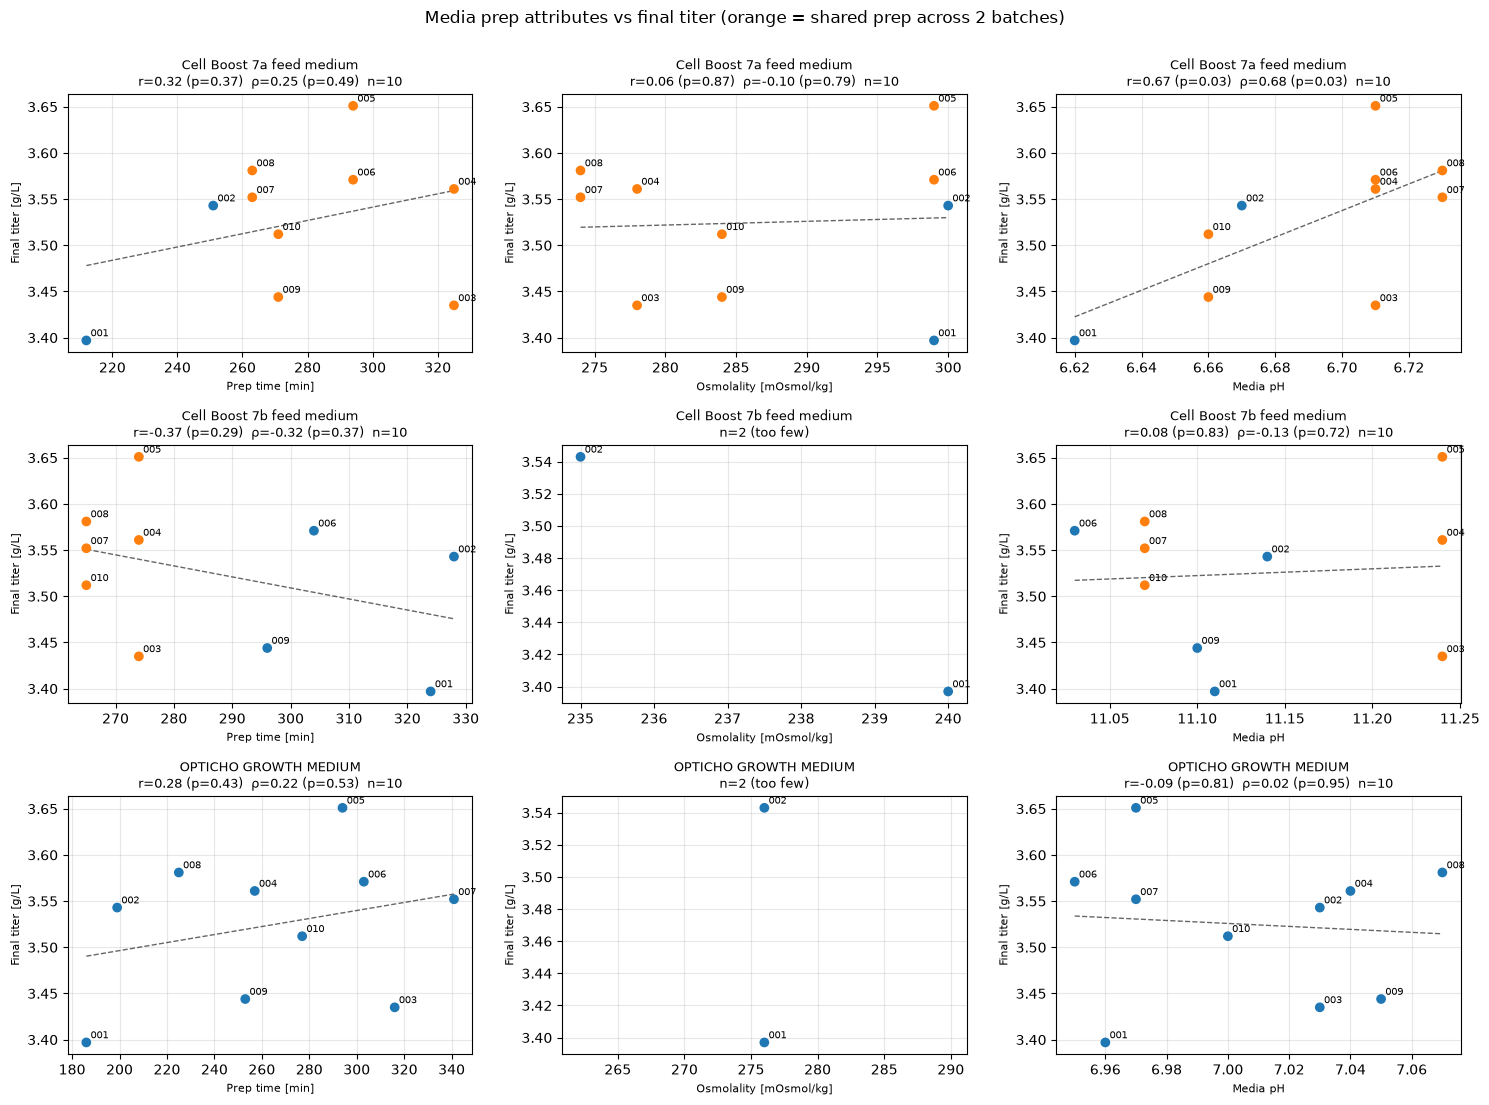

osmolality coverage per media type (non-null / rows):
media_type
Cell Boost 7a feed medium    10/10
Cell Boost 7b feed medium     2/10
OPTICHO GROWTH MEDIUM         2/10


In [5]:
ATTRS = [("prep_time_min", "Prep time [min]"), ("osmo", "Osmolality [mOsmol/kg]"), ("media_ph", "Media pH")]
MEDIA_TYPES = sorted(df["media_type"].unique())

def corr_label(x, y):
    m = x.notna() & y.notna()
    n = int(m.sum())
    if n < 3 or x[m].nunique() < 2:
        return None, f"n={n} (too few)"
    pr, pp = stats.pearsonr(x[m], y[m])
    sr, sp = stats.spearmanr(x[m], y[m])
    return (pr, pp, sr, sp, n), f"r={pr:.2f} (p={pp:.2f})  ρ={sr:.2f} (p={sp:.2f})  n={n}"

results = []
fig, axes = plt.subplots(len(MEDIA_TYPES), len(ATTRS), figsize=(15, 11))
for i, mt in enumerate(MEDIA_TYPES):
    sub = df[df["media_type"] == mt]
    for j, (attr, label) in enumerate(ATTRS):
        ax = axes[i, j]
        x, y = sub[attr].astype(float), sub["final_titer"].astype(float)
        vals, txt = corr_label(x, y)
        ax.scatter(x, y, c=np.where(sub["shared_prep"], "tab:orange", "tab:blue"), zorder=3)
        for _, r in sub.iterrows():
            if pd.notna(r[attr]) and pd.notna(r["final_titer"]):
                ax.annotate(r["CAMPAIGN"][2:], (r[attr], r["final_titer"]), fontsize=7,
                            xytext=(3, 3), textcoords="offset points")
        m = x.notna() & y.notna()
        if vals and x[m].nunique() > 1:
            fit = np.polyfit(x[m], y[m], 1)
            xs = np.linspace(x[m].min(), x[m].max(), 20)
            ax.plot(xs, np.polyval(fit, xs), "k--", lw=1, alpha=0.6)
            results.append({"media_type": mt, "attribute": attr, "pearson_r": vals[0],
                            "pearson_p": vals[1], "spearman_rho": vals[2], "spearman_p": vals[3], "n": vals[4]})
        ax.set_title(f"{mt}\n{txt}", fontsize=9)
        ax.set_xlabel(label, fontsize=8); ax.set_ylabel("Final titer [g/L]", fontsize=8)
        ax.grid(alpha=0.3)
fig.suptitle("Media prep attributes vs final titer (orange = shared prep across 2 batches)", y=1.0)
plt.tight_layout()
fig.savefig(f"{ASSETS}/scatter_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print("osmolality coverage per media type (non-null / rows):")
print(df.groupby("media_type")["osmo"].agg(lambda s: f"{s.notna().sum()}/{len(s)}").to_string())

## 4b. Media lot vs titer

Two views: the **raw-material lot** recorded for each prep, and the prep itself
(preps of one material lot can still differ). With ≤10 runs and mostly 1–2 runs per lot,
this is descriptive — a Kruskal–Wallis test is only run where ≥2 lots have ≥3 runs each.

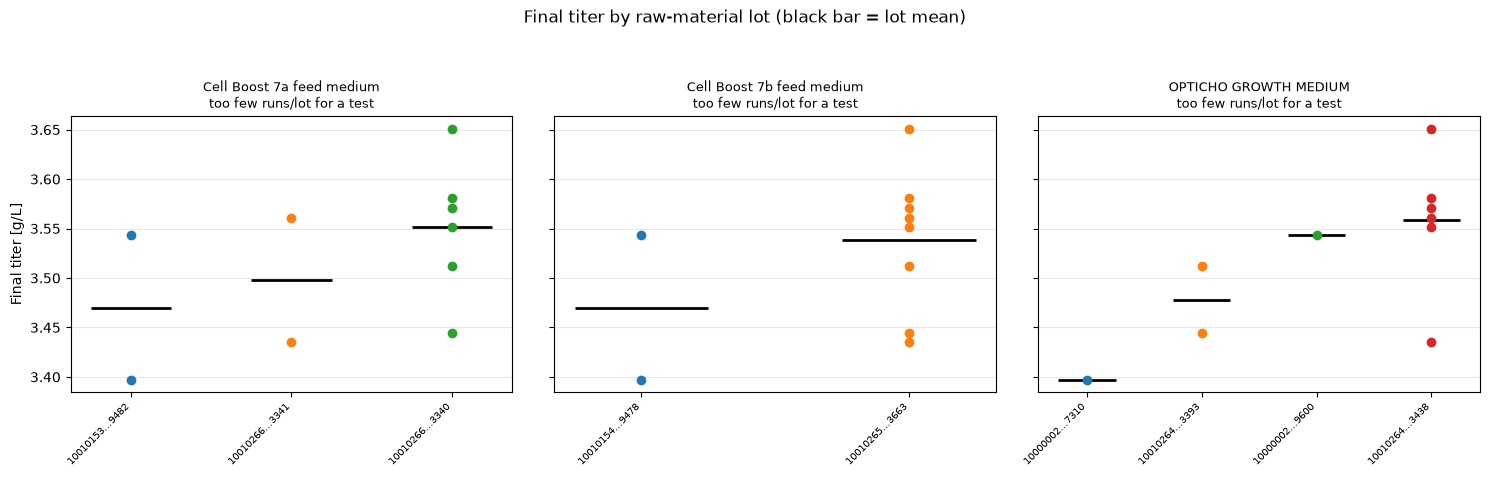

                                               count                                                      list
media_type                material_lot                                                                        
Cell Boost 7a feed medium 10010153_0010009482      2                                            [GA001, GA002]
                          10010266_0010013340      6                [GA005, GA006, GA007, GA008, GA009, GA010]
                          10010266_0010013341      2                                            [GA003, GA004]
Cell Boost 7b feed medium 10010154_0010009478      2                                            [GA001, GA002]
                          10010265_0010013663      8  [GA003, GA004, GA005, GA006, GA007, GA008, GA009, GA010]
OPTICHO GROWTH MEDIUM     10000002_0010007310      1                                                   [GA001]
                          10000002_0010009600      1                                                   [GA002]
 

In [6]:
fig, axes = plt.subplots(1, len(MEDIA_TYPES), figsize=(15, 4.5), sharey=True)
for j, mt in enumerate(MEDIA_TYPES):
    ax = axes[j]
    sub = df[(df["media_type"] == mt) & df["final_titer"].notna()].copy()
    sub["lot"] = sub["material_lot"].fillna("(missing)")
    short = {l: (l[:8] + "\u2026" + l[-4:] if len(l) > 14 else l) for l in sub["lot"].unique()}
    order = sub.groupby("lot")["final_titer"].mean().sort_values().index
    for k, lot in enumerate(order):
        vals = sub.loc[sub["lot"] == lot, "final_titer"]
        ax.scatter(np.full(len(vals), k), vals, zorder=3)
        ax.hlines(vals.mean(), k - 0.25, k + 0.25, color="k", lw=2)
    ax.set_xticks(range(len(order)), [short[l] for l in order], rotation=45, ha="right", fontsize=7)
    groups = [g["final_titer"].values for _, g in sub.groupby("lot") if len(g) >= 3]
    kw = f"Kruskal–Wallis p={stats.kruskal(*groups).pvalue:.2f}" if len(groups) >= 2 else "too few runs/lot for a test"
    ax.set_title(f"{mt}\n{kw}", fontsize=9)
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("Final titer [g/L]")
fig.suptitle("Final titer by raw-material lot (black bar = lot mean)", y=1.05)
plt.tight_layout()
fig.savefig(f"{ASSETS}/titer_by_lot.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby(["media_type", "material_lot"], dropna=False)["CAMPAIGN"].agg(["count", list]).to_string())

## 4c. Correlation over time (day 3 → harvest)

Does an attribute's relationship with titer emerge early and persist, or only appear at harvest?
Pearson correlation of each attribute vs each daily IgG sample point, per media type.


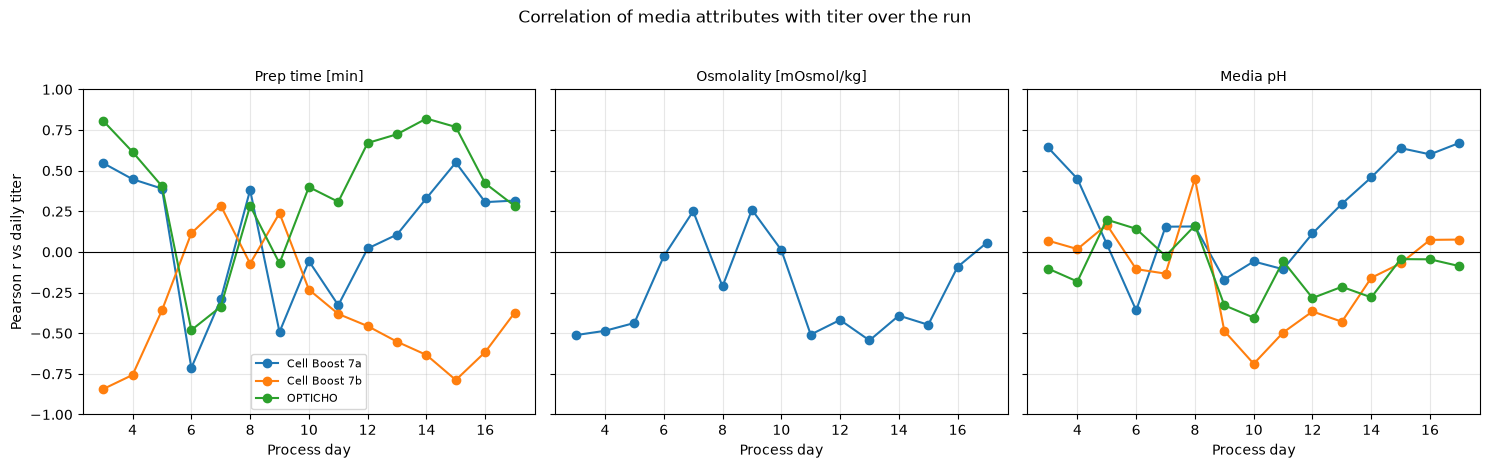

In [7]:
fig, axes = plt.subplots(1, len(ATTRS), figsize=(15, 4.5), sharey=True)
for j, (attr, label) in enumerate(ATTRS):
    ax = axes[j]
    for mt in MEDIA_TYPES:
        sub = df[df["media_type"] == mt]
        days, corrs = [], []
        for d in day_cols:
            x, y = sub[attr].astype(float), sub[d].astype(float)
            m = x.notna() & y.notna()
            if m.sum() >= 3 and x[m].nunique() > 1:
                days.append(sample_day[int(d[1:])]); corrs.append(stats.pearsonr(x[m], y[m])[0])
        ax.plot(days, corrs, marker="o", label=mt.replace(" feed medium", "").replace(" GROWTH MEDIUM", ""))
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylim(-1, 1); ax.set_xlabel("Process day"); ax.set_title(label, fontsize=10); ax.grid(alpha=0.3)
axes[0].set_ylabel("Pearson r vs daily titer"); axes[0].legend(fontsize=8)
fig.suptitle("Correlation of media attributes with titer over the run", y=1.03)
plt.tight_layout()
fig.savefig(f"{ASSETS}/corr_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Results summary

In [8]:
res = pd.DataFrame(results)

def verdict(row):
    if row["n"] < 5:
        return "too few points"
    strong, sig = abs(row["spearman_rho"]) >= 0.6, row["spearman_p"] < 0.1
    if strong and sig:
        return "possible signal — investigate"
    if strong:
        return "trend, not significant"
    return "no relationship"

res["verdict"] = res.apply(verdict, axis=1)
res.sort_values(["attribute", "media_type"]).round(2)

,media_type,attribute,pearson_r,pearson_p,spearman_rho,spearman_p,n,verdict
2,Cell Boost 7a feed medium,media_ph,0.67,0.03,0.68,0.03,10,possible signal — investigate
4,Cell Boost 7b feed medium,media_ph,0.08,0.83,-0.13,0.72,10,no relationship
6,OPTICHO GROWTH MEDIUM,media_ph,-0.09,0.81,0.02,0.95,10,no relationship
1,Cell Boost 7a feed medium,osmo,0.06,0.87,-0.10,0.79,10,no relationship
0,Cell Boost 7a feed medium,prep_time_min,0.32,0.37,0.25,0.49,10,no relationship
3,Cell Boost 7b feed medium,prep_time_min,-0.37,0.29,-0.32,0.37,10,no relationship
5,OPTICHO GROWTH MEDIUM,prep_time_min,0.28,0.43,0.22,0.53,10,no relationship


### Interpretation & caveats (for Raphaël)

- **Missingness**: osmolality and prep time are not recorded for every prep; each panel states its n.
- **Prep time = prep duration (min)**, not media age before use — prep dates are not in the extract.
- **Shared preps**: batch pairs using one prep (orange points) are not independent observations,
  which effectively halves n for Cell Boost media.
- **Osmolality is only well-recorded for Cell Boost 7a** (10/10 runs); it is missing for most
  Cell Boost 7b and OPTICHO preps, so the osmo question can only be answered for 7a with this extract.
- With 10 runs, treat everything here as **prioritization for follow-up**, not proof: attributes marked
  "no relationship" can be deprioritized; any "possible signal" deserves a look with more batches
  (the mCALR FA campaigns use the same media system and could add power).
- **GA009 is not an outlier**: an earlier pass used the Feature table's daily columns, where GA009's
  last two measurements are missing, making its "final" titer a day-12 value (2.75). Its true harvest
  titer is 3.44 g/L — mid-pack. All runs finish in a narrow 3.40–3.65 g/L band.
